In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("car_dataset.csv")

In [12]:
df.head()

,Brand,Mileage,Year,Price
0,Lexus,46723,2017,45697
1,Audi,17442,2009,15888
2,Audi,34533,2023,29609
3,Lexus,146695,2007,44525
4,Audi,117220,2017,26851


In [4]:
df.shape

(5000, 4)

In [9]:
df = df.rename(columns={
    "Car Brand": "Brand",
    "Mileage (km)": "Mileage",
    "Year of Make": "Year",
    "Price (USD)": "Price"
})


In [14]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply to "Car Brand" column
df["Brand"] = label_encoder.fit_transform(df["Brand"])

print(df.head())  # Now "Car Brand" is numeric


   Brand  Mileage  Year  Price
0      1    46723  2017  45697
1      0    17442  2009  15888
2      0    34533  2023  29609
3      1   146695  2007  44525
4      0   117220  2017  26851


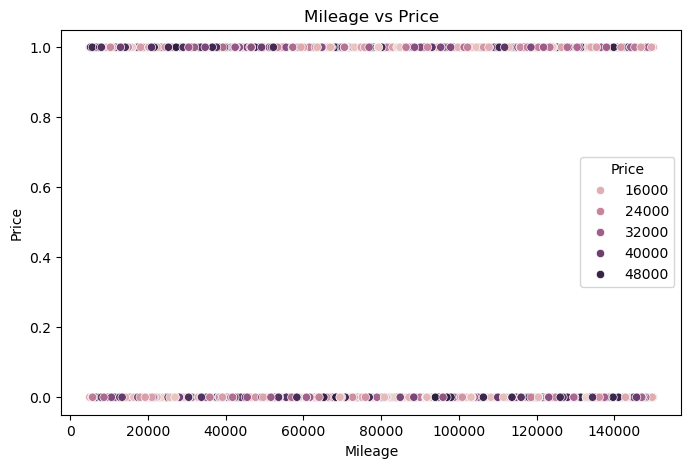

In [23]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Mileage"], y=df["Brand"], hue=df["Price"])
plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

In [26]:
df

,Brand,Mileage,Year,Price
0,1,46723,2017,45697
1,0,17442,2009,15888
2,0,34533,2023,29609
3,1,146695,2007,44525
4,0,117220,2017,26851
...,...,...,...,...
4995,0,69420,2015,14884
4996,0,51641,2005,32741
4997,1,8052,2013,44213
4998,1,59384,2021,17225


In [29]:
X = df.iloc[:,0:3]
y = df.iloc[:,-1]

In [50]:
# train to split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error


In [51]:
# Initialize the Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)  # Adjust depth to prevent overfitting

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)


In [52]:
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")


Mean Absolute Error: 10182.78


📉 Decision Tree MAE: 10203.56
🔥 XGBoost MAE: 10222.89 (Better than Decision Tree!)


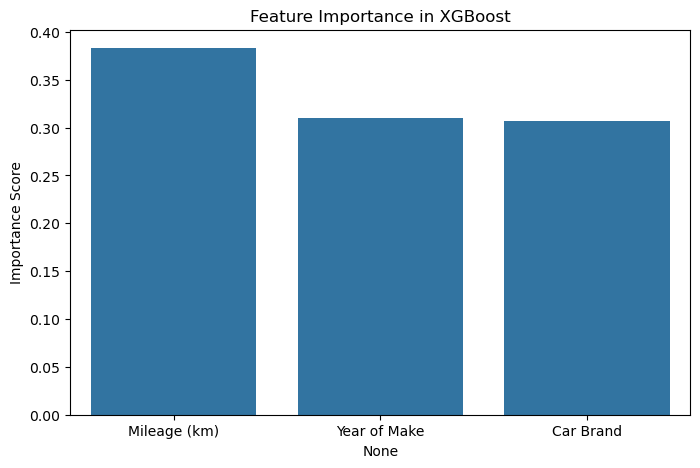

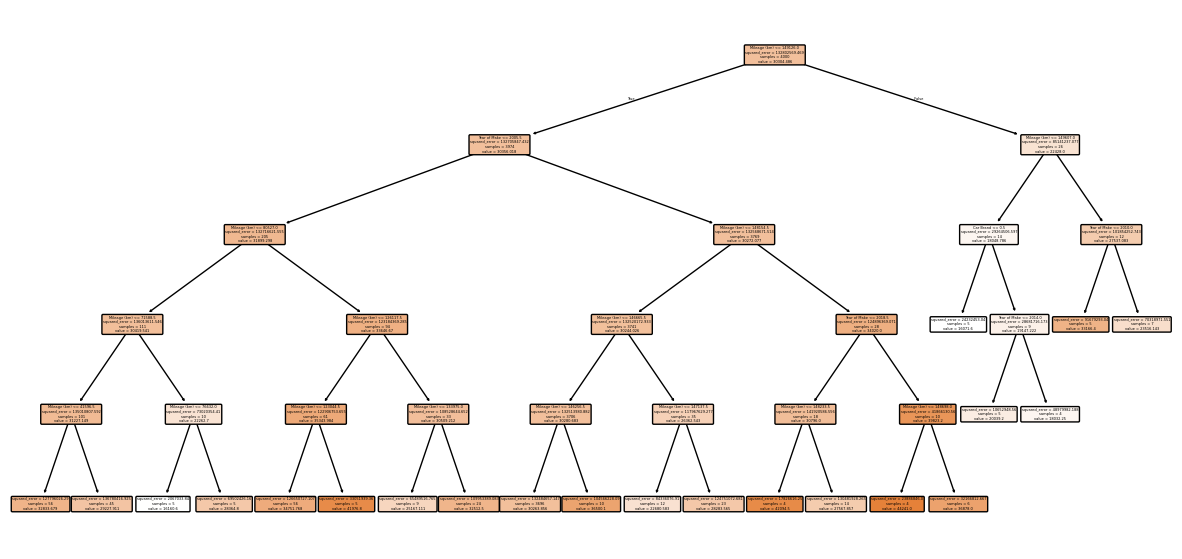

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# 1️⃣ Load dataset
df = pd.read_csv("car_dataset.csv")  # Replace with the actual dataset path

# 2️⃣ Convert categorical column ("Car Brand") into numbers
df["Car Brand"] = df["Car Brand"].astype("category").cat.codes

# 3️⃣ Define input (X) and target (y)
X = df[["Mileage (km)", "Year of Make", "Car Brand"]]  # Features
y = df["Price (USD)"]  # Target variable

# 4️⃣ Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5️⃣ Train Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=5, min_samples_split=5, min_samples_leaf=4, random_state=42)
dt_model.fit(X_train, y_train)

# 6️⃣ Predict and evaluate Decision Tree
y_pred_dt = dt_model.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
print(f"📉 Decision Tree MAE: {mae_dt:.2f}")

# 7️⃣ Train XGBoost Regressor
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

# 8️⃣ Predict and evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
print(f"🔥 XGBoost MAE: {mae_xgb:.2f} (Better than Decision Tree!)")

# 9️⃣ Feature Importance Plot
importance = xgb_model.feature_importances_
plt.figure(figsize=(8, 5))
sns.barplot(x=X.columns, y=importance)
plt.title("Feature Importance in XGBoost")
plt.ylabel("Importance Score")
plt.show()

# 🔟 Visualize Decision Tree (Optional)
plt.figure(figsize=(15, 7))
plot_tree(dt_model, feature_names=X.columns, filled=True, rounded=True)
plt.show()
